In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load Datasets
df = pd.read_csv("/kaggle/input/datasets/rhythmghai/netflix-user-watching-behavior-dataset/netflix_user_behavior_dataset.csv")
print(df.shape)
print(df.head())
print('\nTypes:', df.dtypes)
print('\nColumns:', df.columns.tolist())
print('\nNull Values:', df.isnull().sum())

(50000, 20)
   user_id  age  gender country  account_age_months subscription_type  \
0  U100000   56    Male   India                  17          Standard   
1  U100001   46  Female     USA                  20          Standard   
2  U100002   32   Other     USA                  25             Basic   
3  U100003   60    Male  Canada                  37          Standard   
4  U100004   25    Male  Brazil                  23           Premium   

   monthly_fee payment_method primary_device  devices_used favorite_genre  \
0        15.99         PayPal         Laptop             1         Sci-Fi   
1        12.99         PayPal         Tablet             2    Documentary   
2        15.99         PayPal         Tablet             2         Comedy   
3        12.99         PayPal       Smart TV             3         Action   
4        12.99         PayPal         Mobile             3         Horror   

   avg_watch_time_minutes  watch_sessions_per_week  binge_watch_sessions  \
0         

In [7]:
print(df.describe())

                age  account_age_months   monthly_fee  devices_used  \
count  50000.000000        50000.000000  50000.000000  50000.000000   
mean      40.979240           29.874000     12.323340      1.999140   
std       13.528733           17.051104      3.309109      0.818238   
min       18.000000            1.000000      7.990000      1.000000   
25%       29.000000           15.000000      7.990000      1.000000   
50%       41.000000           30.000000     12.990000      2.000000   
75%       53.000000           45.000000     15.990000      3.000000   
max       64.000000           59.000000     15.990000      3.000000   

       avg_watch_time_minutes  watch_sessions_per_week  binge_watch_sessions  \
count            50000.000000             50000.000000          50000.000000   
mean               154.946520                 9.986920              7.002520   
std                 83.727292                 5.480616              4.335819   
min                 10.000000           

In [8]:
cat_cols = ['gender', 'country', 'subscription_type', 'payment_method', 'primary_device', 'favorite_genre', 'churned']

for col in cat_cols:
    print(f'\n{col}:\n', df[col].value_counts())



gender:
 gender
Female    16759
Male      16737
Other     16504
Name: count, dtype: int64

country:
 country
Brazil       5116
USA          5087
India        5028
Spain        5027
Germany      5024
Australia    5004
Canada       4959
UK           4929
France       4919
Japan        4907
Name: count, dtype: int64

subscription_type:
 subscription_type
Standard    19931
Premium     15196
Basic       14873
Name: count, dtype: int64

payment_method:
 payment_method
PayPal         12539
Credit Card    12502
UPI            12496
Debit Card     12463
Name: count, dtype: int64

primary_device:
 primary_device
Mobile      12585
Smart TV    12562
Laptop      12509
Tablet      12344
Name: count, dtype: int64

favorite_genre:
 favorite_genre
Documentary    6352
Romance        6282
Comedy         6259
Thriller       6257
Action         6235
Horror         6223
Drama          6203
Sci-Fi         6189
Name: count, dtype: int64

churned:
 churned
No     40036
Yes     9964
Name: count, dtype: int64


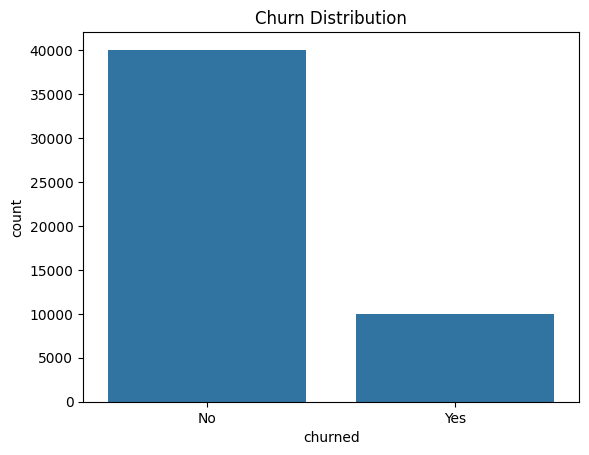

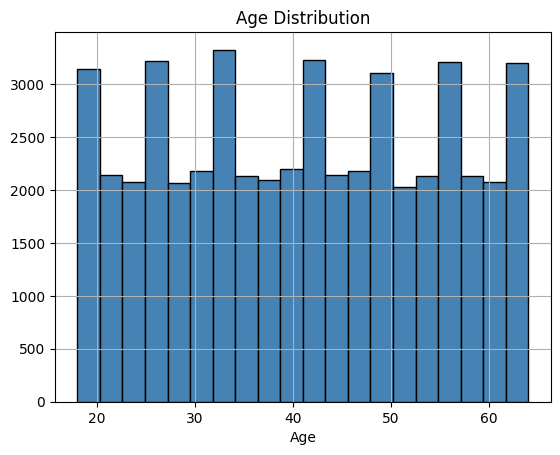

In [9]:
# Churn Distribution
sns.countplot(x='churned', data=df)
plt.title('Churn Distribution')
plt.show()

# Age Distribution
df['age'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

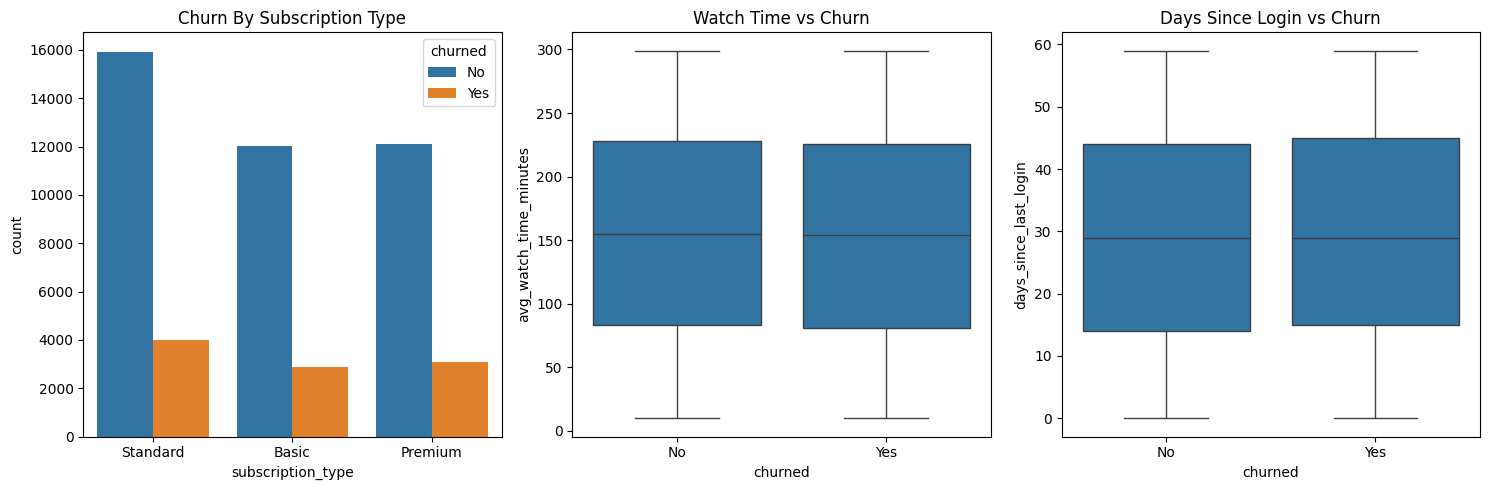

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Churn By Subscription Type
sns.countplot(x='subscription_type', hue='churned', data=df, ax=axes[0])
axes[0].set_title('Churn By Subscription Type')

# Churn By Average Watch Time
sns.boxplot(x='churned', y='avg_watch_time_minutes', data=df, ax=axes[1])
axes[1].set_title('Watch Time vs Churn')

# Churn By Days Since Last Login
sns.boxplot(x='churned', y='days_since_last_login', data=df, ax=axes[2])
axes[2].set_title('Days Since Login vs Churn')

plt.tight_layout()
plt.show()

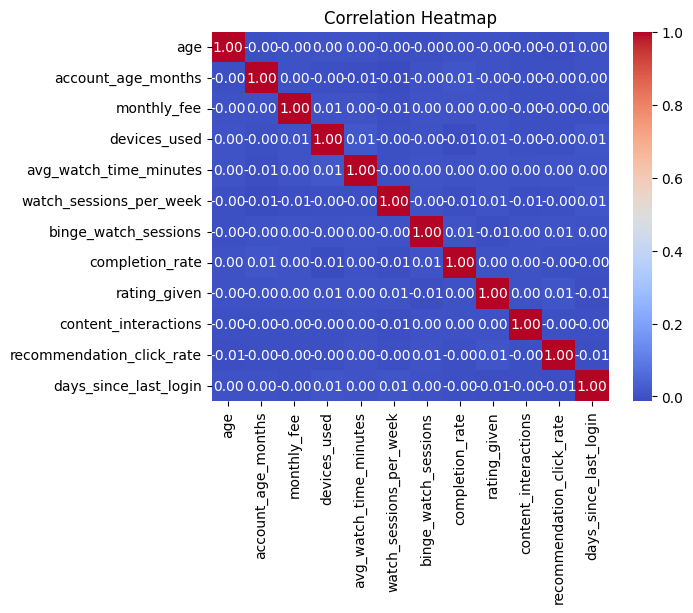

In [13]:
# Correlation Heatmap
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

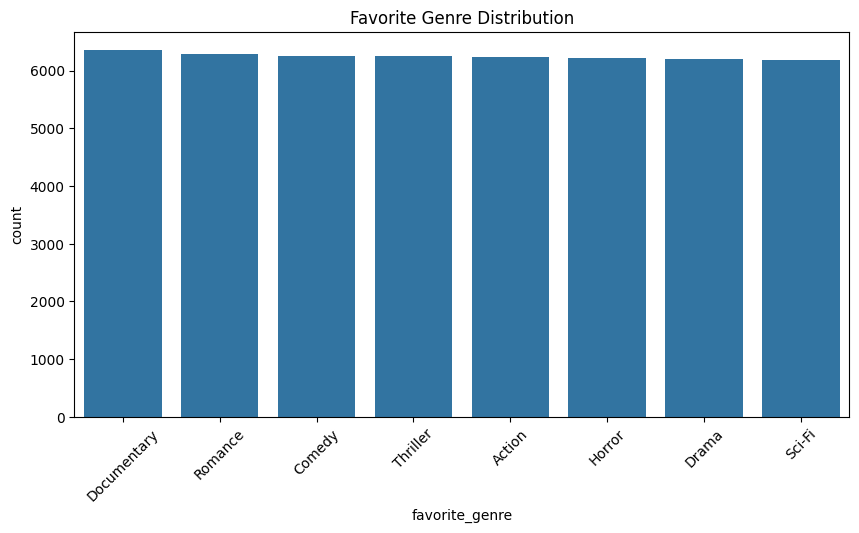

In [16]:
# Favorite Genre Count
plt.figure(figsize=(10,5))
sns.countplot(x='favorite_genre', data=df, order=df['favorite_genre'].value_counts().index)
plt.title('Favorite Genre Distribution')
plt.xticks(rotation=45)
plt.show()

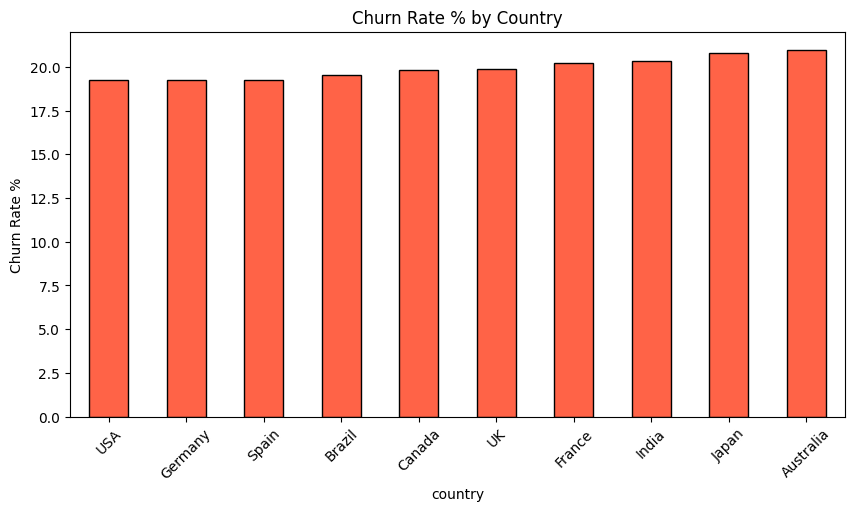

In [17]:
# Churn Rate by Country
plt.figure(figsize=(10,5))
churn_by_country = df.groupby('country')['churned'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
churn_by_country.sort_values().plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Churn Rate % by Country')
plt.ylabel('Churn Rate %')
plt.xticks(rotation=45)
plt.show()

## Key Insights from EDA

1. **Dataset is synthetic** - All features are perfectly balanced 
   across gender, country, device, genre — not realistic

2. **Churn rate is ~20%** - 40,036 retained vs 9,964 churned users
   - Class imbalance exists, need SMOTE for ML modeling

3. **Standard plan churns most** - Higher churn than Premium/Basic

4. **Days since last login matters** - Churned users were less 
   recently active — best churn predictor found

5. **Watch time doesn't predict churn** - Similar watch time 
   for both churned and retained users

6. **No feature correlations exist** - All numeric features 
   are independent (confirmed synthetic data)

7. **Next Step:** Build a Churn Prediction ML model using 
   Random Forest or XGBoost